In [1]:
from math import prod

classes = ['Spam' , 'Ham']
prior = {'Spam' : 0.4 , 'Ham' : 0.6}
likelihood = {
    'Spam' : {'free' : 0.7 , 'urgent' : 0.6} ,
    'Ham' : {'free' : 0.2 , 'urgent' : 0.1}
}
X = {'free' , 'urgent'}

scores = {}
for c  in classes :
    px_given_c = prod([likelihood[c][token] for token in X])
    scores[c] = px_given_c  * prior[c]

pred = max(scores , key=scores.get)
print(scores)
print(pred)

{'Spam': 0.168, 'Ham': 0.012000000000000002}
Spam


In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

train_texts = ['free urgent offer' , 'free free urgent' , 'meeting schedule' , 'project discussion']
labels = ['Spam' , 'Spam' , 'Harm' , 'Harm']

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_texts)
model = MultinomialNB()
model.fit(X_train , labels)

test_text = ['i am meeting']
X_test = vectorizer.transform(test_text)
pred = model.predict_proba(X_test)
pred , model.classes_

(array([[0.7027027, 0.2972973]]), array(['Harm', 'Spam'], dtype='<U4'))

In [3]:
print('class prior p(C)')
print(model.class_log_prior_)

print('feature log probailty p(word|c)')
print(model.feature_log_prob_)

print('voca')
print(vectorizer.get_feature_names_out)

class prior p(C)
[-0.69314718 -0.69314718]
feature log probailty p(word|c)
[[-1.70474809 -2.39789527 -1.70474809 -2.39789527 -1.70474809 -1.70474809
  -2.39789527]
 [-2.56494936 -1.178655   -2.56494936 -1.87180218 -2.56494936 -2.56494936
  -1.46633707]]
voca
<bound method CountVectorizer.get_feature_names_out of CountVectorizer()>


In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report
from sklearn.model_selection import cross_val_score

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

# 4. 예측 및 성능 평가
y_pred = model.predict(X_test)
print(f"정확도: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test , y_pred))

scores = cross_val_score(model , iris.data , iris.target , cv = 5)
print(f'각 폴드의 정확도 {scores}')
print(f'평균 정확도 {scores.mean()}')

정확도: 0.90
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.75      1.00      0.86         9
           2       1.00      0.73      0.84        11

    accuracy                           0.90        30
   macro avg       0.92      0.91      0.90        30
weighted avg       0.93      0.90      0.90        30

각 폴드의 정확도 [1.         0.96666667 0.9        0.9        1.        ]
평균 정확도 0.9533333333333334


In [5]:
from math import sqrt
import numpy as np
from collections import Counter

train_X = np.array([[1,1],[2,1],[4,4],[5,4]])
train_Y = np.array([0,0,1,1])
query = np.array([2,2])
k = 3

def euclidean(p,q):
    return sqrt(sum((p-q)**2))

dists = [(euclidean(query,x),int(y)) for x,y in zip(train_X , train_Y)]
dists.sort(key=lambda x : x[0])
knn = [l for _,l in dists[:k]]
pred = Counter(knn).most_common(1)[0][0]
print(dists)
print(knn)
print(pred)

[(1.0, 0), (1.4142135623730951, 0), (2.8284271247461903, 1), (3.605551275463989, 1)]
[0, 0, 1]
0


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42 , stratify=y)
kgc = KNeighborsClassifier(n_neighbors=20)
kgc.fit(X_train,y_train)
y_pred = kgc.predict(X_test)
print(classification_report(y_test,y_pred))

scores = cross_val_score(KNeighborsClassifier(n_neighbors=4) , iris.data , iris.target , cv = 5)
print(f'각 폴드의 정확도 {scores}')
print(f'평균 정확도 {scores.mean()}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

각 폴드의 정확도 [0.96666667 0.96666667 0.96666667 0.96666667 1.        ]
평균 정확도 0.9733333333333334


In [7]:
students = ["A", "B", "C", "D"]
study_hours      = [1,  3,  5,  2]   # 공부 시간
attendance_rate  = [0.4, 0.7, 0.9, 0.5]   # 출석률
score_true       = [28, 52, 74, 39]   # 실제 시험 점수
pass_true        = [0,  1,  1,  0]    # 합격(1) / 불합격(0)

print("=== 공통 데이터셋 ===")
for i, name in enumerate(students):
    print(f"  학생 {name}: study={study_hours[i]}h, "
          f"attendance={attendance_rate[i]}, "
          f"score={score_true[i]}, pass={pass_true[i]}")

=== 공통 데이터셋 ===
  학생 A: study=1h, attendance=0.4, score=28, pass=0
  학생 B: study=3h, attendance=0.7, score=52, pass=1
  학생 C: study=5h, attendance=0.9, score=74, pass=1
  학생 D: study=2h, attendance=0.5, score=39, pass=0


In [8]:
import math

def sigmoid(z):
    """
    시그모이드 함수: 임의의 실수 z를 0~1 사이로 변환
    σ(z) = 1 / (1 + e^(-z))
    """
    #### [ 빈칸: 이 부분을 완성하세요 — 시그모이드 수식 ]
    return 1 / (1 + math.exp(-z))

def logistic_score(study, attendance, w_study, w_att, bias):
    """
    로지스틱 회귀의 raw score 계산
    z = w_study * study + w_att * attendance + bias
    """
    #### [ 빈칸: 이 부분을 완성하세요 — z = wx + b ]
    return w_study * study + w_att * attendance + bias

# 이론 4에서 설정한 가중치
w_study = 2.0
w_att   = 1.5
bias    = -5.0

print("\n=== Step 4: 로지스틱 회귀 분류 ===")
print(f"  설정: w_study={w_study}, w_attendance={w_att}, bias={bias}")
print(f"  {'학생':^4} | {'z(raw score)':>12} | {'σ(z)':>8} | {'예측':^10} | {'실제':^6} | {'일치':^4}")
print("  " + "-" * 60)

all_correct = True
for i, name in enumerate(students):
    z = logistic_score(study_hours[i], attendance_rate[i], w_study, w_att, bias)
    prob = sigmoid(z)
    predicted = 1 if prob >= 0.5 else 0
    correct = "✓" if predicted == pass_true[i] else "✗"
    if predicted != pass_true[i]:
        all_correct = False
    label_pred = "합격(1)" if predicted == 1 else "불합격(0)"
    label_true = "합격(1)" if pass_true[i] == 1 else "불합격(0)"
    print(f"  학생 {name}  | {z:>12.4f} | {prob:>8.3f} | {label_pred:^10} | {label_true:^8} | {correct:^4}")

print(f"\n  결론: {'4명 전원 올바르게 분류됨 ✓' if all_correct else '일치하지 않는 샘플 있음 ✗'}")


=== Step 4: 로지스틱 회귀 분류 ===
  설정: w_study=2.0, w_attendance=1.5, bias=-5.0
   학생  | z(raw score) |     σ(z) |     예측     |   실제   |  일치 
  ------------------------------------------------------------
  학생 A  |      -2.4000 |    0.083 |   불합격(0)   |  불합격(0)  |  ✓  
  학생 B  |       2.0500 |    0.886 |   합격(1)    |  합격(1)   |  ✓  
  학생 C  |       6.3500 |    0.998 |   합격(1)    |  합격(1)   |  ✓  
  학생 D  |      -0.2500 |    0.438 |   불합격(0)   |  불합격(0)  |  ✓  

  결론: 4명 전원 올바르게 분류됨 ✓


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

X,y = make_blobs(
    n_samples=200 , centers=3 , cluster_std= 1.5 , random_state=42
)
k = 3
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=k , random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

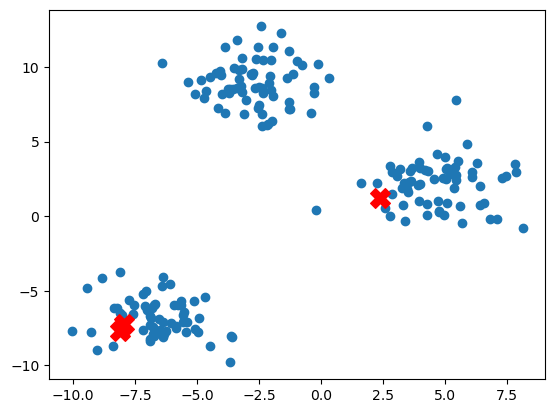

In [45]:
np.random.seed(42)
indices = np.random.choice(len(X) , k , replace=False)
centroids = X[indices]
plt.scatter(X[:,0] , X[:,1])
plt.scatter(centroids[:,0] , centroids[:,1] , c='red' , marker='X' , s= 200)
plt.show()

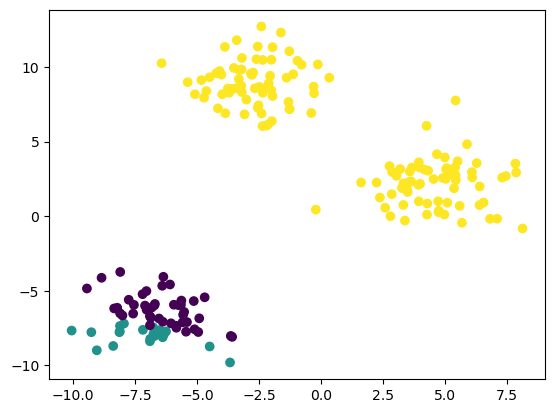

In [63]:
# step 2 각 점을 가장 가까운 중심에 할당
# 거리 계산 -> 가장 가까운 중심 선택
def assign_cluster(X,centroids):
    dist = np.linalg.norm(X[:,np.newaxis] - centroids , axis=2)
    return np.argmin(dist,axis=1)
labels = assign_cluster(X,centroids)
labels

plt.scatter(X[:,0] , X[:,1] , c = labels)
plt.show()

In [59]:
X[:,np.newaxis].shape

(200, 1, 2)

In [ ]:
X[labels == 0].mean(axis=0)
def update_centroid(X,labels,k):
    return np.array(
        [X[labels == i].mean(axis = 0) for i in range(k)]
    )
centroids = update_centroid(X,labels,k)
centroids

# 새로운 중심점을 좌표에 업데이트
# 새로운 중심점을 기준으로 label을 분리해서 시각화



array([[-6.44654121, -6.2472099 ],
       [-7.14174892, -8.01691097],
       [ 0.94735044,  5.54722254]])